### Fatima kamal Abu Azab
### 2320224611
### ML-Ass.1-Data Preprocessing

#### For this lab, we will be using the following libraries:

pandas for managing the data.

numpy for mathematical operations.

seaborn for visualizing the data.

matplotlib for visualizing the data.

In [125]:
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

The training and testing datasets are loaded using pandas.  
The training dataset contains the target variable `SalePrice`, while the test dataset is used for predictions.

In [126]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

#Let's read the data into pandas data frame and look at the first 5 rows using the head() method.
print(train.head())


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

### Dataset Dimensions

The shape of the datasets is displayed to identify the number of rows and columns in both training and testing datasets.

In [127]:
print(" Train shape : ", train.shape)
print(" Test shape : ", test.shape)

 Train shape :  (1460, 81)
 Test shape :  (1459, 80)


We can find more information about the features and types using the info() method.

In [128]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [129]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

Next, let's use the describe() function to show the count, mean, min, max of the sale price attribute.

In [130]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [131]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


The describe() function reveals the statistical information about the numeric attributes. To reveal some information about our categorical (object) attributes

### Memory Optimization

Some columns are loaded using optimized data types such as `category` and smaller integer types to reduce memory usage.

In [132]:
train = pd.read_csv("data/train.csv", dtype={"MSSubClass":"category", "Neighborhood":"category"})


In [133]:
train.dtypes[["MSSubClass", "Neighborhood"]]


MSSubClass      category
Neighborhood    category
dtype: object

In [134]:
train_int = pd.read_csv("data/train.csv")  
train_cat = pd.read_csv("data/train.csv", dtype={"MSSubClass":"category", "Neighborhood":"category"})

print(train_int.memory_usage(deep=True).sum())
print(train_cat.memory_usage(deep=True).sum())


3600842
3514332


### Missing Values Handling

Missing values are analyzed carefully.  
Some missing values represent the absence of a feature rather than actual missing data, so appropriate filling strategies are applied.

In [135]:
train.isnull().sum()


Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [136]:
train.isnull().sum()[train.isnull().sum() > 0]


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### Why Median Was Used Instead of Mean

The median was used to fill missing numerical values because it is less sensitive to extreme values and outliers compared to the mean. This helps preserve the overall distribution of the data.

In [137]:
special_fill = {
    "Alley":"NoAlley",
    "PoolQC":"NoPool",
    "Fence":"NoFence",
    "MiscFeature":"None",
    "FireplaceQu":"NoFireplace"
}

#General function for filling by column type
def fill_missing(df):
    for col in df.columns[df.isnull().any()]:
        if col in special_fill:  
            df[col] = df[col].fillna(special_fill[col]) 
        elif df[col].dtype in ["float64","int64"]:  
            df[col] = df[col].fillna(df[col].median())    
        else:  
            df[col] = df[col].fillna(df[col].mode()[0])   

#Applying the function to train, test
fill_missing(train)
fill_missing(test)

print("Train missing:", train.isnull().sum().sum())
print("Test missing:", test.isnull().sum().sum())


Train missing: 0
Test missing: 0


### Outlier Detection and Removal

Outliers are identified using visualizations and removed when they negatively affect model performance.

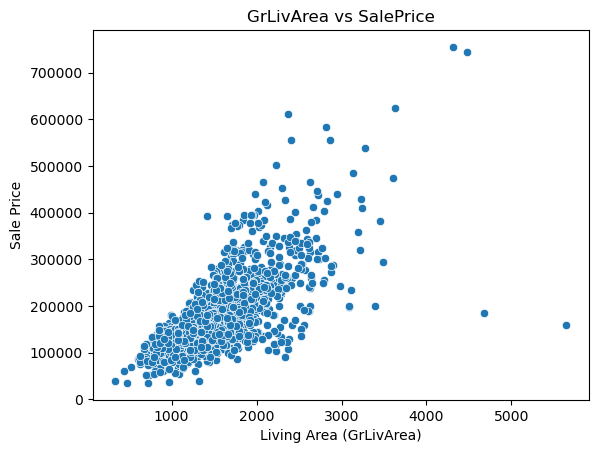

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.xlabel("Living Area (GrLivArea)")
plt.ylabel("Sale Price")
plt.title("GrLivArea vs SalePrice")
plt.show()


In [139]:
train = train.drop(train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)].index)


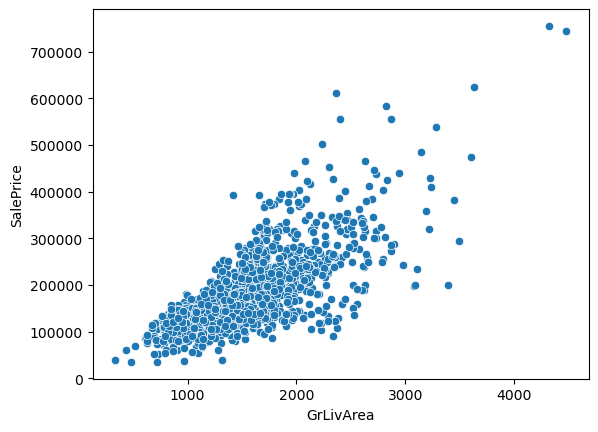

In [140]:
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.show()


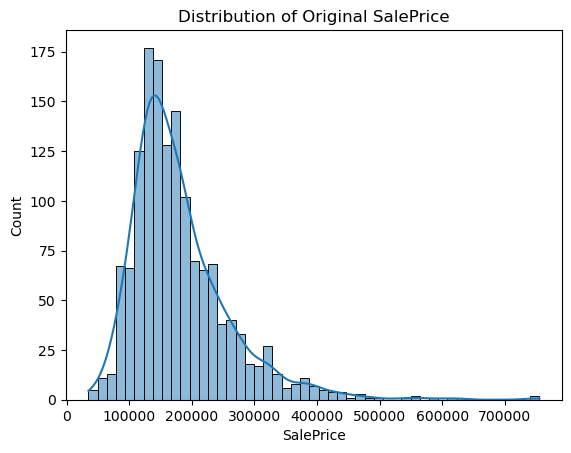

In [141]:
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution of Original SalePrice")
plt.show()


In [142]:
import numpy as np

train["SalePrice"] = np.log1p(train["SalePrice"])


### Data Transformation

The target variable `SalePrice` is log-transformed to reduce skewness and improve the distribution.

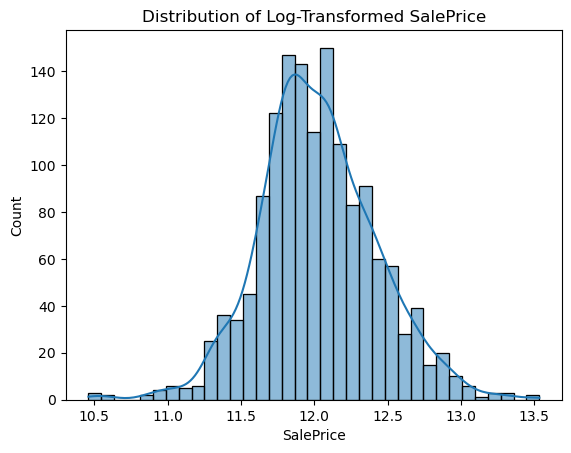

In [143]:
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution of Log-Transformed SalePrice")
plt.show()


In [144]:
#The data was temporarily merged so that the same transformations could be applied.
all_data = pd.concat([train.drop("SalePrice", axis=1), test], axis=0)

#Converting classification columns to numerical format
all_data = pd.get_dummies(all_data)

#Separate them again
X = all_data.iloc[:len(train), :]
test = all_data.iloc[len(train):, :]

#the goal
y = train["SalePrice"]


### Correlation Analysis

Correlation analysis is performed to identify the features most strongly related to house prices.

SalePrice      1.000000
OverallQual    0.821405
GrLivArea      0.725211
GarageCars     0.681033
GarageArea     0.656129
TotalBsmtSF    0.647563
Name: SalePrice, dtype: float64


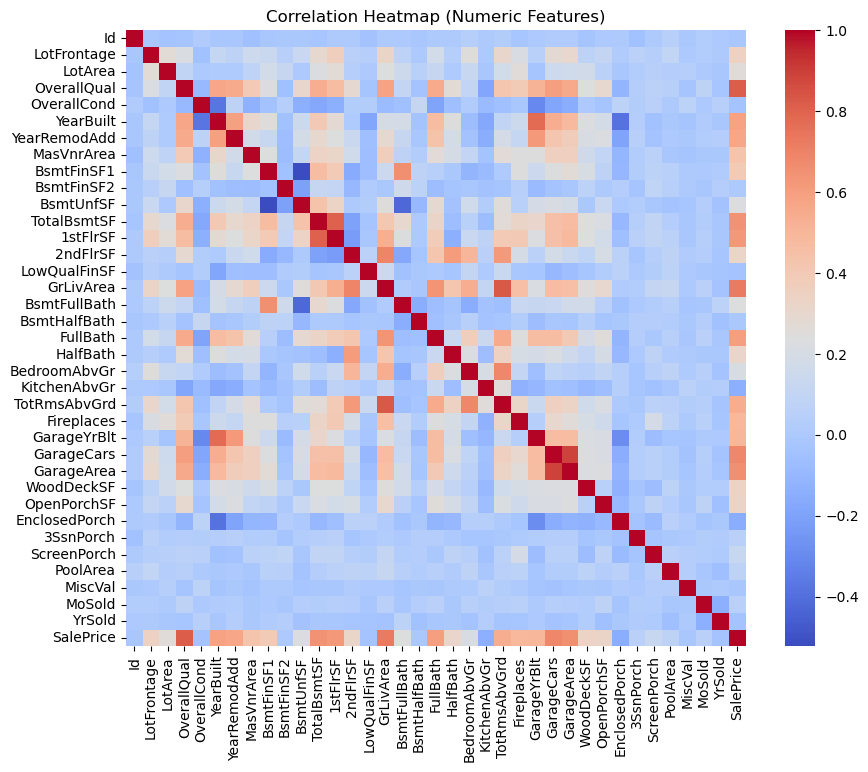

In [145]:
#Digital column testing only
numeric_train = train.select_dtypes(include=["int64","float64"])

#Calculate the correlation matrix
corr_matrix = numeric_train.corr()

#Extracting the top 5 attributes related to SalePrice
top_corr = corr_matrix["SalePrice"].sort_values(ascending=False).head(6)
print(top_corr)

#Heatmap drawing
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


### Scatter Plot Visualization

A scatter plot is used to visualize the relationship between living area and house price while considering house quality.

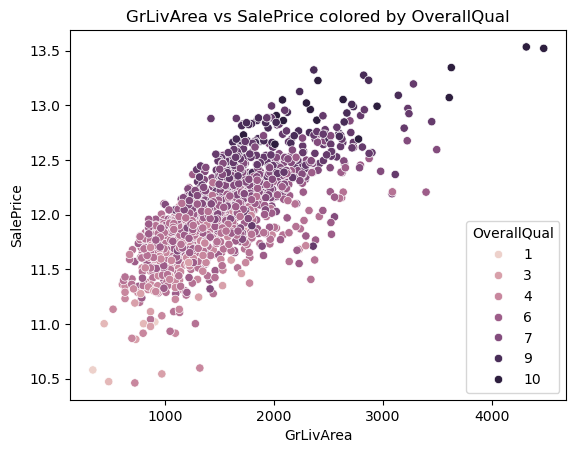

In [146]:
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"], hue=train["OverallQual"])
plt.title("GrLivArea vs SalePrice colored by OverallQual")
plt.show()


### Neighborhood Analysis

This visualization compares house prices across different neighborhoods to discover geographical patterns.

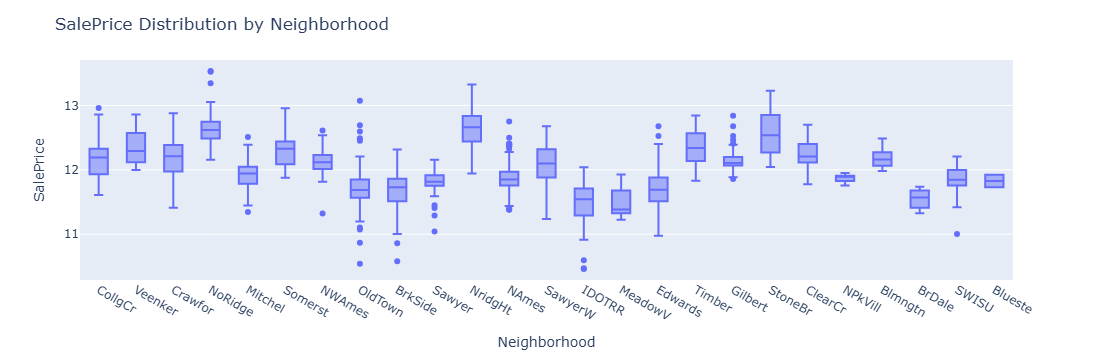

In [147]:
import plotly.express as px

fig = px.box(train, x="Neighborhood", y="SalePrice")
fig.update_layout(title="SalePrice Distribution by Neighborhood")
fig.show()


### Feature Engineering

New features are created to improve the predictive power of the dataset.

In [151]:
train.loc[:, "TotalSF"] = train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]
test.loc[:, "TotalSF"] = test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"]


### Encoding Categorical Variables

Categorical variables are converted into numerical representations using Label Encoding and One-Hot Encoding techniques.

In [152]:
from sklearn.preprocessing import LabelEncoder

ordinal_features = ["ExterQual", "KitchenQual"]

for col in ordinal_features:
    if col in train.columns and col in test.columns: 
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])
        test[col] = le.transform(test[col])


### Pipeline Construction

A reusable preprocessing function is created to ensure consistent transformations for both training and testing datasets.

In [164]:

def preprocess_data(df):
    special_fill = {
        "Alley": "NoAlley",
        "PoolQC": "NoPool",
        "Fence": "NoFence",
        "MiscFeature": "None"
    }
    
    for col, value in special_fill.items():

        if col in df.columns:
            df[col] = df[col].fillna(value)

    if all(col in df.columns for col in ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]):

            df["TotalSF"] = (
            df["TotalBsmtSF"] +
            df["1stFlrSF"] +
            df["2ndFlrSF"]
        )

    return df
train = preprocess_data(train)
test = preprocess_data(test)

### Model Preparation

The dataset is split into input features and the target variable before training the machine learning model.

In [165]:
y = train["SalePrice"]

X = train.drop("SalePrice", axis=1)


In [166]:
print(train.shape)
print(test.shape)


(1458, 323)
(1459, 323)


In [167]:
print(y.head())   
print(X.head())


0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64
   Id  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1         65.0     8450            7            5       2003   
1   2         80.0     9600            6            8       1976   
2   3         68.0    11250            7            5       2001   
3   4         60.0     9550            7            5       1915   
4   5         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  SaleType_ConLw  \
0          2003       196.0         706           0  ...           False   
1          1976         0.0         978           0  ...           False   
2          2002       162.0         486           0  ...           False   
3          1970         0.0         216           0  ...           False   
4          2000       350.0         655           0  ...           False   

   SaleType_New  SaleType_O

In [168]:
print(X.dtypes.value_counts())

bool       285
int64       34
float64      3
Name: count, dtype: int64


In [169]:
X = X.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)
test = test.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)

In [170]:
print(X.dtypes.value_counts())

int64      319
float64      3
Name: count, dtype: int64
